# Vision Mamba on AMD GPU with ROCm

[State Space Models (SSMs)](https://arxiv.org/abs/2111.00396), such as [Mamba](https://arxiv.org/abs/2312.00752) model with its efficient hardware-aware design, have emerged as a potential alternative to Transformer models. Various efforts have been made to develop vision backbones using only SSMs, yielding promising results. This blog will explore [Vision Mamba](https://arxiv.org/abs/2401.09417) (Vim), an innovative and efficient backbone for vision tasks, and evaluate its performance on AMD GPUs. For more details on SSMs, Mamba, and its performance on AMD hardware, we recommend reading our blog [Mamba on AMD GPUs with ROCm](https://rocm.blogs.amd.com/artificial-intelligence/mamba/README.html).

## Vision Mamba
Vision Mamba (Vim) is motivated by the Mamba in language modeling and it extends its principles to vision tasks. However, due to the inherent differences between language and vision tasks, directly applying Mamba to vision tasks is ineffective. This is because Mamba’s unidirectional modeling, suited for sequential data, lacks positional awareness crucial for vision tasks. To overcome this, Vim introduces a bidirectional selective state space model (SSM) for global visual context modeling and incorporates position embeddings for location-aware visual recognition.

Vim first splits the input image into patches, which are linearly projected into vectors. These patches are treated as sequential data within Vim blocks, where the bidirectional SSM efficiently compresses the visual representations. Specifically, within each Vim block, the input token sequence (embedded patches) is first normalized, then linearly projected into x and z. The x sequence is processed from both forward and backward directions, and the outputs from these two paths are gated by z and combined to produce the final output token sequence. Additionally, the position embeddings provide spatial awareness, making Vim more robust for dense prediction tasks. With its generic and efficient visual backbone, enhanced by the advanced SSM approach, Vim offers an innovative solution for visual modeling. We encourage readers to refer to the [Vim paper](https://arxiv.org/abs/2401.09417) for more details.

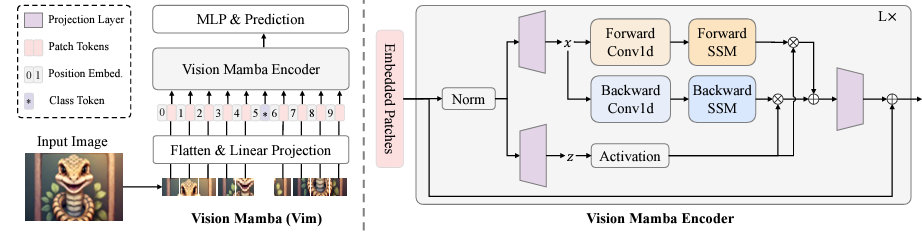

Image source: [Vision Mamba paper](https://arxiv.org/abs/2401.09417)



## Vision Mamba Training and Inference on AMD GPU with ROCm
The [Vision Mamba repo](https://github.com/hustvl/Vim) hosts the source code for the Mamba model. There is an additional step you need to take to install and run the Vision Mamba on AMD GPUs with ROCm. The [causal-conv1d](https://github.com/hustvl/Vim/tree/main/causal-conv1d) and [mamba-1p1p1](https://github.com/hustvl/Vim/tree/main/mamba-1p1p1) folders have the CUDA source code which has incorporated the hardware-aware optimization for the bidirectional Mamba. PyTorch uses a tool called [`Hipify_torch`](https://github.com/ROCm/hipify_torch) to translate CUDA source code to HIP C++, making custom kernels suitable for running on ROCm. This translation process is called internally by PyTorch during the building of the CUDA extension, ensuring a seamless experience when using custom kernels on ROCm. For more details, we encourage you to read about [HIPIFY](https://github.com/ROCm/HIPIFY?tab=readme-ov-file) and [`Hipify_torch`](https://github.com/ROCm/hipify_torch). Fortunately, we have already completed this part, so you can directly install and use the Vision Mamba model on AMD GPUs with ROCm using the following steps.


### Setup

This blog was created using the following setup. For comprehensive support details about the setup, please refer to the [ROCm documentation](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/).

* Hardware & OS:
  * [AMD Instinct GPU](https://www.amd.com/en/products/accelerators/instinct.html)
  * Ubuntu 22.04.3 LTS
* Software:
  * [ROCm 6.1+](https://rocm.docs.amd.com/projects/install-on-linux/en/develop/how-to/amdgpu-install.html)
  * [PyTorch 2.1+ for ROCm](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/how-to/3rd-party/pytorch-install.html)
  
In this blog, we utilize the [`rocm6.2_ubuntu20.04_py3.9_pytorch_release_2.1.2`](https://hub.docker.com/layers/rocm/pytorch/rocm6.2_ubuntu20.04_py3.9_pytorch_release_2.1.2/images/sha256-58186da550e3d83c5b598ce0c1f581206eabd82c85bd77d22b34f5695d749762?context=explore) docker image on a Linux machine equipped with MI210 GPUs and the AMD GPU driver version 6.7.0.

Note: *If your machine does not have ROCm installed or if you need to update the driver, follow the steps show in [ROCm installation via AMDGPU installer](https://rocm.docs.amd.com/projects/install-on-linux/en/develop/how-to/amdgpu-install.html). In this blog, We install ROCm, including the GPU driver, using the package [`amdgpu-install_6.1.60101-1_all.deb`](https://repo.radeon.com/amdgpu-install/6.1.1/ubuntu/jammy/amdgpu-install_6.1.60101-1_all.deb) for ROCm.*


### Getting Started

We use the [`rocm/pytorch:rocm6.2_ubuntu20.04_py3.9_pytorch_release_2.1.2`](https://hub.docker.com/layers/rocm/pytorch/rocm6.2_ubuntu20.04_py3.9_pytorch_release_2.1.2/images/sha256-58186da550e3d83c5b598ce0c1f581206eabd82c85bd77d22b34f5695d749762?context=explore) Docker image and build Vision Mamba in the container.

In [ ]:
%%bash
docker pull rocm/pytorch:rocm6.2_ubuntu20.04_py3.9_pytorch_release_2.1.2
docker run -it --name vision_mamba --rm --ipc=host \
            --device=/dev/kfd --device=/dev/dri/ \
            --group-add=video --shm-size 8G \
            rocm/pytorch:rocm6.2_ubuntu20.04_py3.9_pytorch_release_2.1.2

Build and install Vision Mamba on AMD GPU with ROCm.

In [ ]:
%%bash
git clone https://github.com/AMD-AI/Vim.git
cd Vim 
git checkout add_rocm_support

pip install -r vim/vim_requirements.txt
pip install -e ./causal-conv1d
pip install -e ./mamba-1p1p1

There are three different size of the models for Vim:
| Model | #param. | Top-1 Acc. | Top-5 Acc. | 
|:------------:|:-------------:|:----------:|:----------:|
| [Vim-tiny](https://huggingface.co/hustvl/Vim-tiny-midclstok)    |       7M       |   76.1   | 93.0 |
| [Vim-tiny<sup>+</sup>](https://huggingface.co/hustvl/Vim-tiny-midclstok)    |       7M       |   78.3   | 94.2 |
| [Vim-small](https://huggingface.co/hustvl/Vim-small-midclstok)    |       26M       |   80.5   | 95.1 |
| [Vim-small<sup>+</sup>](https://huggingface.co/hustvl/Vim-small-midclstok)    |       26M       |   81.6   | 95.4 |
| [Vim-base](https://huggingface.co/hustvl/Vim-base-midclstok)    |       98M       |   81.9   | 95.8 |

This blog uses Vim-small<sup>+</sup> in the following test. <sup>+</sup> means the model has been finetuned at finer granularity with short schedule. Please use the following command to download the weights for Vim-small<sup>+</sup>.

In [ ]:
%%bash
wget https://huggingface.co/hustvl/Vim-small-midclstok/resolve/main/vim_s_midclstok_ft_81p6acc.pth

After completing these steps, you will obtain a weight file for Vim-small (e.g., vim_s_midclstok_ft_81p6acc.pth).
To proceed with training and accuracy testing, you'll need the [ImageNet dataset](https://www.image-net.org/challenges/LSVRC/index.php), a popular benchmark for vision models. Use the following command to download it. Depending on your network speed, this process may take several hours.

>**Note:**
If you only need to do inference, then you can skip the dataset downloading.


In [ ]:
%%bash
mkdir image_dataset
cd image_dataset
wget https://image-net.org/data/ILSVRC/2012/ILSVRC2012_img_val.tar
wget https://image-net.org/data/ILSVRC/2012/ILSVRC2012_img_train.tar
mkdir train && mv ILSVRC2012_img_train.tar train/ && cd train
tar -xvf ILSVRC2012_img_train.tar && rm -f ILSVRC2012_img_train.tar
find . -name "*.tar" | while read NAME ; do mkdir -p "${NAME%.tar}"; tar -xvf "${NAME}" -C "${NAME%.tar}"; rm -f "${NAME}"; 
rm train/n04266014/n04266014_10835.JPEG
cd ..
mkdir val && mv ILSVRC2012_img_val.tar val/ && cd val && tar -xvf ILSVRC2012_img_val.tar
wget -qO- https://raw.githubusercontent.com/soumith/imagenetloader.torch/master/valprep.sh | bash

At this point, we have everything set up for accuracy testing, training, and inference with Vision Mamba on AMD GPUs using ROCm. We’ll now cover each step in detail.

### Accuracy Test
In this section, we will evaluate the accuracy of Vision Mamba (small) on the ImageNet dataset downloaded previously.

In [ ]:
%%bash
cd Vim
python ./vim/main.py --eval --resume ./vim_s_midclstok_ft_81p6acc.pth \
    --model vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2  \
    --data-path ./image_dataset

You should see outputs similar to the one shown below.

```text
Namespace(batch_size=64, epochs=300, bce_loss=False, unscale_lr=False, model='vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2', input_size=224, drop=0.0, drop_path=0.1, model_ema=True, model_ema_decay=0.99996, model_ema_force_cpu=False, opt='adamw', opt_eps=1e-08, opt_betas=None, clip_grad=None, momentum=0.9, weight_decay=0.05, sched='cosine', lr=0.0005, lr_noise=None, lr_noise_pct=0.67, lr_noise_std=1.0, warmup_lr=1e-06, min_lr=1e-05, decay_epochs=30, warmup_epochs=5, cooldown_epochs=10, patience_epochs=10, decay_rate=0.1, color_jitter=0.3, aa='rand-m9-mstd0.5-inc1', smoothing=0.1, train_interpolation='bicubic', repeated_aug=True, train_mode=True, ThreeAugment=False, src=False, reprob=0.25, remode='pixel', recount=1, resplit=False, mixup=0.8, cutmix=1.0, cutmix_minmax=None, mixup_prob=1.0, mixup_switch_prob=0.5, mixup_mode='batch', teacher_model='regnety_160', teacher_path='', distillation_type='none', distillation_alpha=0.5, distillation_tau=1.0, cosub=False, finetune='', attn_only=False, data_path='./image1k2012/tarfile', data_set='IMNET', inat_category='name', output_dir='', device='cuda', seed=0, resume='./vim_s_midclstok_ft_81p6acc.pth', start_epoch=0, eval=True, eval_crop_ratio=0.875, dist_eval=False, num_workers=10, pin_mem=True, distributed=False, world_size=1, dist_url='env://', if_amp=True, if_continue_inf=False, if_nan2num=False, if_random_cls_token_position=False, if_random_token_rank=False, local_rank=0, gpu=None)
Creating model: vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2
number of params: 26001256
Test:  [  0/521]  eta: 0:54:16  loss: 0.4024 (0.4024)  acc1: 95.8333 (95.8333)  acc5: 97.9167 (97.9167)  time: 6.2496  data: 1.4009  max mem: 1660
Test:  [ 10/521]  eta: 0:19:04  loss: 0.4024 (0.4226)  acc1: 93.7500 (92.6136)  acc5: 98.9583 (98.7689)  time: 2.2405  data: 0.1277  max mem: 1660
Test:  [ 20/521]  eta: 0:17:05  loss: 0.5881 (0.5696)  acc1: 88.5417 (88.2440)  acc5: 98.9583 (98.4127)  time: 1.8360  data: 0.0003  max mem: 1660
...
Test:  [500/521]  eta: 0:00:38  loss: 0.7445 (0.8569)  acc1: 81.2500 (81.6159)  acc5: 96.8750 (95.4300)  time: 1.8321  data: 0.0003  max mem: 1660
Test:  [510/521]  eta: 0:00:20  loss: 0.8264 (0.8635)  acc1: 80.2083 (81.4702)  acc5: 96.8750 (95.3910)  time: 1.8322  data: 0.0002  max mem: 1660
Test:  [520/521]  eta: 0:00:01  loss: 0.7551 (0.8584)  acc1: 80.2083 (81.5600)  acc5: 96.8750 (95.4380)  time: 1.8165  data: 0.0001  max mem: 1660
Test: Total time: 0:15:59 (1.8411 s / it)
* Acc@1 81.560 Acc@5 95.438 loss 0.858
Accuracy of the network on the 50000 test images: 81.6%
```
This result closely matches the figures (Top-1 Acc.(81.6), Top-5 Acc.(95.4)) reported by the author in the [paper](https://github.com/hustvl/Vim?tab=readme-ov-file#model-weights), confirming that the ROCm-enabled setup and our modifications with the `Hipify_torch` are working as expected."

### Vision Mamba Distributed Data Parallel Training on AMD GPU with ROCm
Training can take days long if you use a small GPU. To speed up the process, [DistributedDataParalle](https://pytorch.org/tutorials/intermediate/ddp_tutorial.html) is used to run multiple processes across all 8 AMD Instinct MI210 GPUs. Depending on your GPU type and memory capacity, you need to adjust the `batch_size` and `num_workers` values—either increasing them to maximize resource utilization or reducing them to prevent out-of-memory (OOM) issues. Based on our test, training takes around 5 hours on 8 AMD Instinct MI210 GPUs and 2 hours on 8 AMD Instinct MI300X GPUs.

In [ ]:
%%bash
cd Vim
torchrun --nnodes 1 --nproc_per_node 8 ./vim/main.py \
    --model vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2 \
    --batch-size 128 --lr 5e-6 --min-lr 1e-5 --warmup-lr 1e-5 --drop-path 0.0 --weight-decay 1e-8 --num_workers 8 \
    --data-path  ./image_dataset --output_dir ./output/vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2\
    --epochs 1 --finetune  ./vim_s_midclstok_ft_81p6acc.pth --no_amp

In [ ]:
Outputs:
```text
[2024-09-09 04:43:53,537] torch.distributed.run: [WARNING] 
[2024-09-09 04:43:53,537] torch.distributed.run: [WARNING] *****************************************
[2024-09-09 04:43:53,537] torch.distributed.run: [WARNING] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
[2024-09-09 04:43:53,537] torch.distributed.run: [WARNING] *****************************************
/root/research/Vim/mamba-1p1p1/mamba_ssm/ops/triton/layer_norm.py:147: UserWarning: 'torch._C._CudaDeviceProperties' object has no attribute 'gcnArchName', warp size set to 64 based on device name: AMD Instinct MI210
  warnings.warn(f"{e}, warp size set to {warp_size} based on device name: {device_name}", UserWarning)
/root/research/Vim/mamba-1p1p1/mamba_ssm/ops/triton/layer_norm.py:147: UserWarning: 'torch._C._CudaDeviceProperties' object has no attribute 'gcnArchName', warp size set to 64 based on device name: AMD Instinct MI210
  warnings.warn(f"{e}, warp size set to {warp_size} based on device name: {device_name}", UserWarning)
/root/research/Vim/mamba-1p1p1/mamba_ssm/ops/triton/layer_norm.py:147: UserWarning: 'torch._C._CudaDeviceProperties' object has no attribute 'gcnArchName', warp size set to 64 based on device name: AMD Instinct MI210
  warnings.warn(f"{e}, warp size set to {warp_size} based on device name: {device_name}", UserWarning)
/root/research/Vim/mamba-1p1p1/mamba_ssm/ops/triton/layer_norm.py:147: UserWarning: 'torch._C._CudaDeviceProperties' object has no attribute 'gcnArchName', warp size set to 64 based on device name: AMD Instinct MI210
  warnings.warn(f"{e}, warp size set to {warp_size} based on device name: {device_name}", UserWarning)
/root/research/Vim/mamba-1p1p1/mamba_ssm/ops/triton/layer_norm.py:147: UserWarning: 'torch._C._CudaDeviceProperties' object has no attribute 'gcnArchName', warp size set to 64 based on device name: AMD Instinct MI210
  warnings.warn(f"{e}, warp size set to {warp_size} based on device name: {device_name}", UserWarning)
/root/research/Vim/mamba-1p1p1/mamba_ssm/ops/triton/layer_norm.py:147: UserWarning: 'torch._C._CudaDeviceProperties' object has no attribute 'gcnArchName', warp size set to 64 based on device name: AMD Instinct MI210
  warnings.warn(f"{e}, warp size set to {warp_size} based on device name: {device_name}", UserWarning)
/root/research/Vim/mamba-1p1p1/mamba_ssm/ops/triton/layer_norm.py:147: UserWarning: 'torch._C._CudaDeviceProperties' object has no attribute 'gcnArchName', warp size set to 64 based on device name: AMD Instinct MI210
  warnings.warn(f"{e}, warp size set to {warp_size} based on device name: {device_name}", UserWarning)
/root/research/Vim/mamba-1p1p1/mamba_ssm/ops/triton/layer_norm.py:147: UserWarning: 'torch._C._CudaDeviceProperties' object has no attribute 'gcnArchName', warp size set to 64 based on device name: AMD Instinct MI210
  warnings.warn(f"{e}, warp size set to {warp_size} based on device name: {device_name}", UserWarning)
Namespace(batch_size=64, epochs=2, bce_loss=False, unscale_lr=False, model='vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2', input_size=224, drop=0.0, drop_path=0.0, model_ema=True, model_ema_decay=0.99996, model_ema_force_cpu=False, opt='adamw', opt_eps=1e-08, opt_betas=None, clip_grad=None, momentum=0.9, weight_decay=1e-08, sched='cosine', lr=5e-06, lr_noise=None, lr_noise_pct=0.67, lr_noise_std=1.0, warmup_lr=1e-05, min_lr=1e-05, decay_epochs=30, warmup_epochs=5, cooldown_epochs=10, patience_epochs=10, decay_rate=0.1, color_jitter=0.3, aa='rand-m9-mstd0.5-inc1', smoothing=0.1, train_interpolation='bicubic', repeated_aug=True, train_mode=True, ThreeAugment=False, src=False, reprob=0.25, remode='pixel', recount=1, resplit=False, mixup=0.8, cutmix=1.0, cutmix_minmax=None, mixup_prob=1.0, mixup_switch_prob=0.5, mixup_mode='batch', teacher_model='regnety_160', teacher_path='', distillation_type='none', distillation_alpha=0.5, distillation_tau=1.0, cosub=False, finetune='../blogs/Vim/vim_s_midclstok_ft_81p6acc.pth', attn_only=False, data_path='./2012im1k', data_set='IMNET', inat_category='name', output_dir='./output/vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2', device='cuda', seed=0, resume='', start_epoch=0, eval=False, eval_crop_ratio=0.875, dist_eval=False, num_workers=8, pin_mem=True, distributed=True, world_size=8, dist_url='env://', if_amp=False, if_continue_inf=False, if_nan2num=False, if_random_cls_token_position=False, if_random_token_rank=False, local_rank=0, gpu=0, rank=0, dist_backend='nccl')
num_tasks8, global_rank0
Creating model: vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2
number of params: 26001256
Start training for 2 epochs
Epoch: [0]  [   0/2502]  eta: 22:01:17  lr: 0.000010  loss: 3.1392 (3.1392)  time: 31.6856  data: 7.2020  max mem: 29147
Epoch: [0]  [  10/2502]  eta: 6:44:48  lr: 0.000010  loss: 2.6538 (2.6554)  time: 9.7467  data: 0.6550  max mem: 29347
Epoch: [0]  [  20/2502]  eta: 5:59:07  lr: 0.000010  loss: 2.6421 (2.6574)  time: 7.5312  data: 0.0004  max mem: 29348
Epoch: [0]  [  30/2502]  eta: 5:42:06  lr: 0.000010  loss: 2.7014 (2.6918)  time: 7.5098  data: 0.0004  max mem: 29348
Epoch: [0]  [  40/2502]  eta: 5:32:46  lr: 0.000010  loss: 2.7321 (2.6768)  time: 7.5101  data: 0.0004  max mem: 29348
...
Epoch: [0]  [2490/2502]  eta: 0:01:30  lr: 0.000010  loss: 2.5359 (2.5530)  time: 7.5111  data: 0.0005  max mem: 29350
Epoch: [0]  [2500/2502]  eta: 0:00:15  lr: 0.000010  loss: 2.5442 (2.5530)  time: 7.5123  data: 0.0004  max mem: 29350
Epoch: [0]  [2501/2502]  eta: 0:00:07  lr: 0.000010  loss: 2.5442 (2.5526)  time: 7.5125  data: 0.0004  max mem: 29350
Epoch: [0] Total time: 5:13:40 (7.5222 s / it)
Averaged stats: lr: 0.000010  loss: 2.5442 (2.5540)
* Acc@1 81.390 Acc@5 95.406 loss 0.871
Accuracy of the network on the 50000 test images: 81.4%
Max accuracy: 81.39%
Training time 5:20:30
```

According to the paper, the `vim_s_midclstok_ft_81p6acc.pth` checkpoint was fine-tuned on the ImageNet dataset. Our goal of the training is not to compete with this result by further fine-tuning with different settings. Instead, the primary objective is to verify that Distributed Data-Parallel (DDP) training on AMD GPUs with ROCm functions correctly with our modifications using 'Hipify_torch'.

After the training finished you can find the checkpoints in this path `./output/vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2`.

### Vision Mamba Inference on AMD GPU with ROCm
Vision Mamba is a general vision task backbone and can be used for different inference tasks, e.g., image classification, segmentation, detection, etc. To demonstrate its inference capabilities on AMD GPUs with ROCm, we use the model generated in the previous step for an image classification task. In the following code you can choose the pretrained model or the model you trained in the previous step for the inference task.

In [2]:
!pip install rope

  Using cached rope-1.13.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached pytoolconfig-1.3.1-py3-none-any.whl.metadata (1.4 kB)
Using cached rope-1.13.0-py3-none-any.whl (206 kB)
Using cached pytoolconfig-1.3.1-py3-none-any.whl (17 kB)


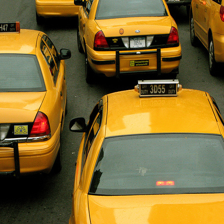

label: class - 468:cab


In [19]:
import torch
from PIL import Image
from torchvision import transforms
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from vim.models_mamba import VisionMamba
from vim.models_mamba import (
    vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2)

# Create Vim model and load the weights
model = vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2()
# using the weights from the dwonloaded file
# sd = torch.load("./vim_s_midclstok_ft_81p6acc.pth")

# using the weights from the training
sd = torch.load("./output/vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2/best_checkpoint.pth")
model.load_state_dict(sd["model"])
model.eval()
model.to("cuda")


def inference(model, image):
    ## preprocess image
    test_image = Image.open(image).convert('RGB')
    test_image.show()
    test_image = test_image.resize((224, 224))
    image_as_tensor = transforms.ToTensor()(test_image)
    normalized_tensor = transforms.Normalize(
        IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
    )(image_as_tensor)

    ## inference with vision mamba
    x = normalized_tensor.unsqueeze(0).cuda()
    pred = model(x)

    ## decode the output and print the class
    import json
    f = open('imagenet_class_index.json')
    class_idx = json.load(f)
    idx2label = [class_idx[str(k)][1] for k in range(len(class_idx))]
    print(f"label: class - {pred.argmax()}:{idx2label[pred.argmax()]}")

inference(model,"cab.png")
inference(model,"cat2.jpeg")

The output looks correct! 

## Conclusion
In this blog, we explored Vision Mamba on AMD GPUs with ROCm, showcasing its capabilities and performance for vision tasks. The hipified Vision Mamba effectively leverages AMD hardware for both training and inference, offering a robust alternative to traditional models. We encourage readers to experiment with Vision Mamba in their computer vision applications.

## Disclaimers
Third-party content is licensed to you directly by the third party that owns the content and is not licensed to you by AMD. ALL LINKED THIRD-PARTY CONTENT IS PROVIDED “AS IS” WITHOUT A WARRANTY OF ANY KIND. USE OF SUCH THIRD-PARTY CONTENT IS DONE AT YOUR SOLE DISCRETION AND UNDER NO CIRCUMSTANCES WILL AMD BE LIABLE TO YOU FOR ANY THIRD-PARTY CONTENT. YOU ASSUME ALL RISK AND ARE SOLELY RESPONSIBLE FOR ANY DAMAGES THAT MAY ARISE FROM YOUR USE OF THIRD-PARTY CONTENT.